# **Imports**

In [47]:
!pip install pmdarima
!pip install git+https://github.com/scikit-learn-contrib/py-earth@v0.2dev

  Cloning https://github.com/scikit-learn-contrib/py-earth (to revision v0.2dev) to /tmp/pip-req-build-bv13jj1b
  Running command git clone -q https://github.com/scikit-learn-contrib/py-earth /tmp/pip-req-build-bv13jj1b
  Running command git checkout -b v0.2dev --track origin/v0.2dev
  Switched to a new branch 'v0.2dev'
  Branch 'v0.2dev' set up to track remote branch 'v0.2dev' from 'origin'.


In [48]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import datetime
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import sklearn
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots  import plot_acf as pltacf
from  statsmodels.tsa.stattools import pacf as PACF
from statsmodels.graphics.tsaplots  import plot_pacf as pltpacf
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [49]:
!gdown --id 1-punuvZD7igSLLHS0vedKbgIIT7M4Pyy

Downloading...
From: https://drive.google.com/uc?id=1-punuvZD7igSLLHS0vedKbgIIT7M4Pyy
To: /content/ICICIBANK.NS.csv
100% 168k/168k [00:00<00:00, 23.6MB/s]


In [50]:
stock_name="ICICIBANK"

In [51]:
df_stock = pd.read_csv('ICICIBANK.NS.csv',index_col='Date')
df_stock.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,237.545456,239.636368,234.545456,239.090912,5998096.0,4,1,1,7791.299805,5.090912
2016-01-04,237.272720,237.590912,231.500000,232.318176,9435792.0,0,4,1,7784.649902,6.090912
2016-01-05,232.954544,234.090912,228.818176,233.363632,8966977.0,1,5,1,7741.000000,5.272736
2016-01-06,232.181824,233.409088,226.545456,227.363632,17416181.0,2,6,1,7568.299805,6.863632
2016-01-07,224.000000,225.181824,221.000000,224.318176,18240712.0,3,7,1,7601.350098,4.181824


#**ARIMA - Autoregression Intergrated Moving Average**

##*Decomposing the data*

In [52]:
df_stock['Close'].head()

Date
2016-01-01    239.090912
2016-01-04    232.318176
2016-01-05    233.363632
2016-01-06    227.363632
2016-01-07    224.318176
Name: Close, dtype: float64

Text(0.5, 1.0, 'Close Price - ICICIBANK')

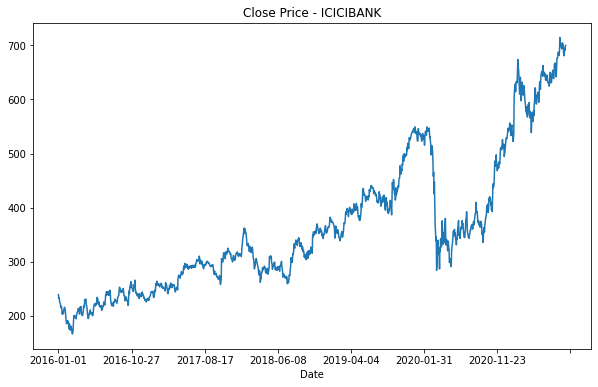

In [53]:
plt.rcParams['figure.figsize'] = (10,6)
df_stock['Close'].plot()
plt.title("Close Price - "+stock_name)

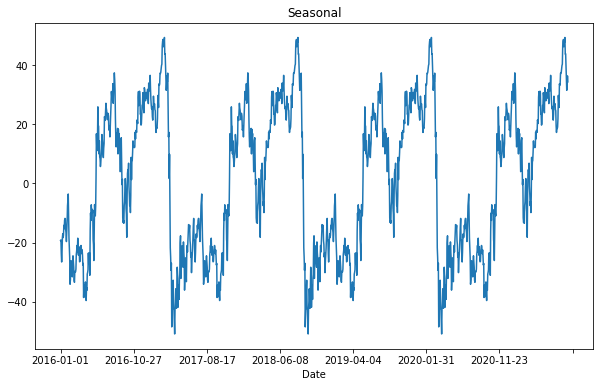

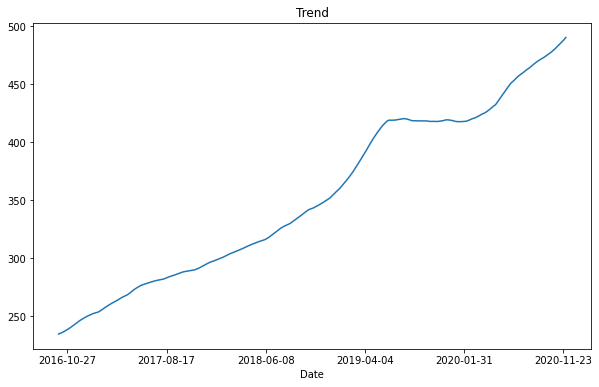

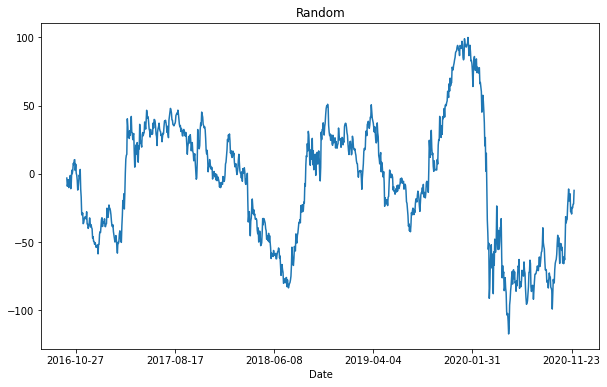

In [54]:
plt.rcParams['figure.figsize'] = (10,6)
decomposition=seasonal_decompose(df_stock['Close'],freq=365)
decomposition.seasonal.plot()
plt.title("Seasonal")
plt.show()
decomposition.trend.plot()
plt.title("Trend")
plt.show()
decomposition.resid.plot()
plt.title("Random")
plt.show()

##*Stationary Check*

In [55]:
Stationary=False
dvalue=0
Stationary_df=df_stock['Close'].copy()
while(Stationary==False):
  dftest = adfuller(Stationary_df.dropna(),autolag='AIC')
  dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
  for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
  print(dftest[1])
  if (dftest[1]>0.05):
    Stationary=False
    Stationary_df = Stationary_df - Stationary_df.shift(1)
  else :
    Stationary=True
  dvalue+=1  
print(dfoutput)
print("Differencing Value : ",dvalue)

0.9548409405366054
7.774202119006335e-14
Test Statistic                -8.580013e+00
p-value                        7.774202e-14
#lags used                     1.800000e+01
number of observations used    1.368000e+03
critical value (1%)           -3.435139e+00
critical value (5%)           -2.863655e+00
critical value (10%)          -2.567896e+00
dtype: float64
Differencing Value :  2


##*ACF*

In [56]:
from  statsmodels.tsa.stattools import acf as ACF
ACFOutput = ACF(Stationary_df.dropna(),nlags=20)
print(ACFOutput)

[ 1.         -0.02341242 -0.03556444 -0.04119289  0.02791469  0.08246016
 -0.06433918  0.02518567  0.02272399  0.02847237  0.01104404 -0.04662888
  0.06082114 -0.01756748 -0.03556594 -0.01485013 -0.02809232  0.09876912
 -0.00652697 -0.07260306  0.01363588]


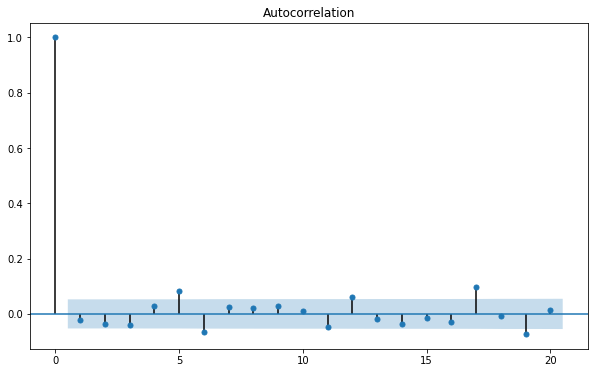

In [57]:
plt.rcParams['figure.figsize'] = (10,6)
pltacf(Stationary_df.dropna(),lags=20)
plt.show()

##*PACF*

In [58]:
PACFOutput = PACF(Stationary_df.dropna(),nlags=20)
print(PACFOutput)

[ 1.         -0.02342931 -0.0361846  -0.04307462  0.02468525  0.08137118
 -0.06091953  0.03053809  0.02629564  0.02230109  0.01301583 -0.03464216
  0.05378977 -0.01926224 -0.03973988 -0.01112257 -0.0307391   0.08192299
  0.00636816 -0.06986579  0.01950006]


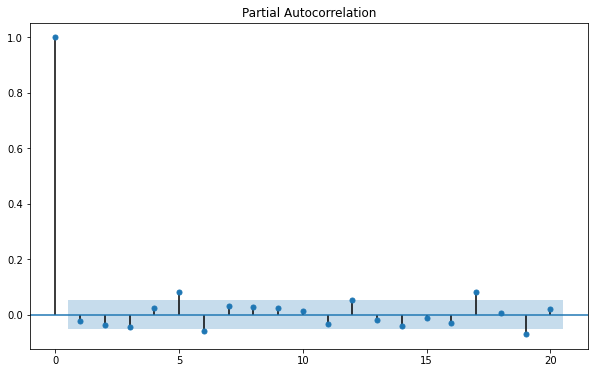

In [59]:
plt.rcParams['figure.figsize'] = (10,6)
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

##*Test and Train Split*

In [60]:
df_stock_train=df_stock.loc['2016-01-01':'2021-07-31']['Close']
df_stock_test=df_stock.loc['2021-07-31':]['Close']

In [61]:
df_stock_train.tail()

Date
2021-07-26    676.750000
2021-07-27    677.450012
2021-07-28    685.049988
2021-07-29    687.500000
2021-07-30    682.500000
Name: Close, dtype: float64

In [62]:
df_stock_test.head()

Date
2021-08-02    681.400024
2021-08-03    690.400024
2021-08-04    714.650024
2021-08-05    702.450012
2021-08-06    697.650024
Name: Close, dtype: float64

##*Model Fitting*

In [63]:
arima_model=auto_arima(df_stock_train,seasonal=False,max_p=2,max_d=2,max_q=2,start_p=0,start_q=0,d=1)

In [64]:
arima_model

ARIMA(maxiter=50, method='lbfgs', order=(0, 1, 0), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=True)

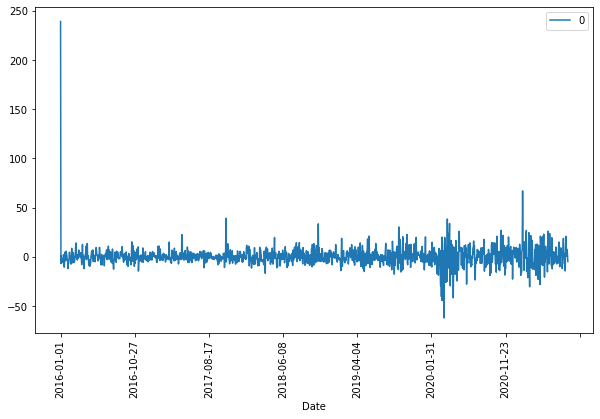

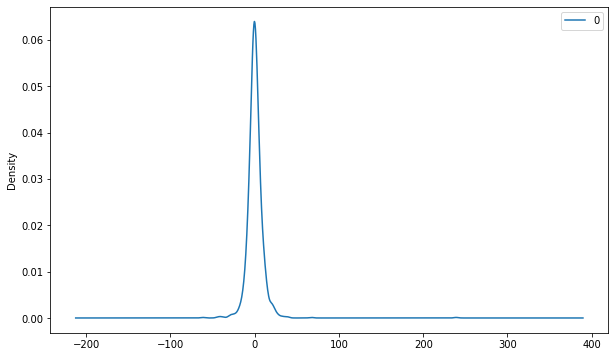

                 0
count  1369.000000
mean      0.517720
std      10.591724
min     -61.988254
25%      -3.674047
50%      -0.081130
75%       4.225198
max     239.090912


In [65]:
model = ARIMA(df_stock_train, order=(1,1,1))
model_fit = model.fit()
residuals = pd.DataFrame(model_fit.resid)
plt.rcParams['figure.figsize'] = (10,6)
residuals.plot()
plt.xticks(rotation=90)
plt.show()
residuals.plot(kind='kde')
plt.show()
print(residuals.describe())

##*Forecasting and Testing*

In [66]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values)):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)
error = np.sqrt(mean_squared_error(df_stock_test.values, predictions))
print('Test Error Percentage',(error/np.mean(df_stock_test.values))*100)

Test Error Percentage 1.247584896870531


([], <a list of 0 Text major ticklabel objects>)

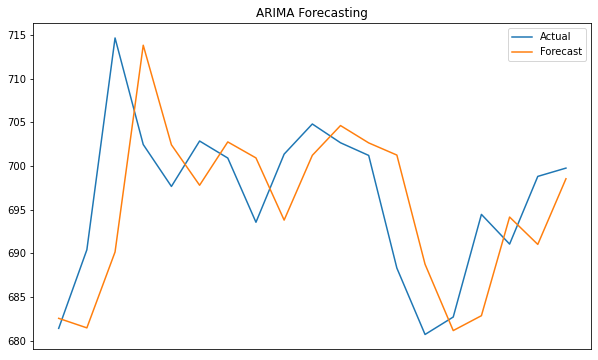

In [67]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(df_stock_test, label='Actual')
plt.plot(predictions, label='Forecast')
plt.title('ARIMA Forecasting')
plt.legend()
plt.xticks([])

##*Forecast for August*

In [68]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values[:14])):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)

In [69]:
predictions

[682.54777995912,
 681.4565183689494,
 690.145260515564,
 713.8186124704744,
 702.4178025735912,
 697.7866557974153,
 702.7470415541591,
 700.9147255730674,
 693.7954245971067,
 701.210544117821,
 704.6212433954819,
 702.635990052614,
 701.2410504119482,
 688.7415706171906]

#**MARS - Multivariate Adaptive Regression Splines**

In [70]:
from pyearth import Earth

In [71]:
df_stock_mars_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:5].copy()
df_stock_mars_test=df_stock.loc['2021-07-31':].iloc[:,:5].copy()

In [72]:
df_stock_mars_train.shape

(1369, 5)

In [73]:
df_stock_mars_test.shape

(19, 5)

In [74]:
df_stock_mars_train.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-01-01,237.545456,239.636368,234.545456,239.090912,5998096.0
2016-01-04,237.272720,237.590912,231.500000,232.318176,9435792.0
2016-01-05,232.954544,234.090912,228.818176,233.363632,8966977.0
2016-01-06,232.181824,233.409088,226.545456,227.363632,17416181.0
2016-01-07,224.000000,225.181824,221.000000,224.318176,18240712.0


In [75]:
df_stock_mars_test

,Open,High,Low,Close,Volume
Date,,,,,
2021-08-02,684.049988,688.049988,677.700012,681.400024,9348206.0
2021-08-03,683.000000,691.900024,676.650024,690.400024,10162609.0
2021-08-04,694.000000,717.400024,693.200012,714.650024,28730606.0
2021-08-05,715.500000,716.500000,699.049988,702.450012,17774554.0
2021-08-06,705.049988,706.000000,695.700012,697.650024,14701949.0
2021-08-09,697.400024,706.299988,694.349976,702.849976,8602980.0
2021-08-10,704.099976,708.299988,697.299988,700.900024,10843554.0
2021-08-11,706.250000,707.150024,690.000000,693.549988,9748084.0
2021-08-12,693.500000,702.950012,693.299988,701.349976,8840339.0


In [76]:
x_train_mars = df_stock_mars_train.drop(['Close'], axis=1)
y_train_mars = df_stock_mars_train['Close']
x_test_mars = df_stock_mars_test.drop(['Close'], axis=1)
y_test_mars = df_stock_mars_test['Close']

##*Fitting the model*

In [77]:
MARS_model = Earth(max_terms = 600,max_degree=3)
MARS_model_fitted = MARS_model.fit(x_train_mars, y_train_mars)
y_pred_mars = MARS_model_fitted.predict(x_test_mars[:14])

##*Evaluating the model*

In [78]:
MSE = mean_squared_error(y_test_mars[:14], y_pred_mars)
RMSE = np.sqrt(MSE)
RMSE_mean = (RMSE/np.mean(y_test_mars[:14]))*100
print("RMSE Score :", round(RMSE, 2))
print("RMSE/Mean", round(RMSE_mean,1))

RMSE Score : 4.11
RMSE/Mean 0.6


##*Plotting Forecast vs Actual* 

([], <a list of 0 Text major ticklabel objects>)

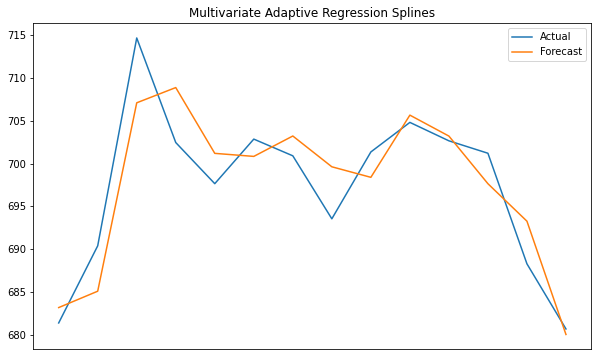

In [79]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(y_test_mars[:14], label='Actual')
plt.plot(y_pred_mars, label='Forecast')
plt.title('Multivariate Adaptive Regression Splines')
plt.legend()
plt.xticks([])

#**VAR - Vector Autoregression**

In [80]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

In [106]:
df_stock_var = df_stock.loc['2016-01-01':'2021-08-20'].iloc[:,:4].copy()
df_stock_var_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:4].copy()
df_stock_var_test=df_stock.loc['2021-07-31':'2021-08-20'].iloc[:,:4].copy()


In [107]:
df_stock_var_train.shape

(1369, 4)

In [108]:
df_stock_var_test.shape

(14, 4)

In [109]:
df_stock_var.shape

(1383, 4)

##*Plotting the Data*

In [110]:
fig, axes = plt.subplots(nrows=4, ncols=1, dpi=120, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df_stock_var[df_stock_var.columns[i]]
    ax.plot(data, linewidth=1)
    # Decorations
    ax.set_title(df_stock_var.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout()

##*Granger Causality Test*

In [111]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

grangers_causation_matrix(df_stock_var, variables = df_stock_var.columns)        

,Open_x,High_x,Low_x,Close_x
Open_y,1.0,0.0,0.0000,0.0
High_y,0.0,1.0,0.0000,0.0
Low_y,0.0,0.0,1.0000,0.0
Close_y,0.0,0.0,0.0085,1.0


##*Cointegration Test*

In [112]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df_stock_var, alpha=0.05): 
    out = coint_johansen(df_stock_var,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    print('Name   ::  Test Statistic > C(95%)    =>   Significance  \n', '--'*20)
    for col, trace, cvt in zip(df_stock_var.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df_stock_var)

Name   ::  Test Statistic > C(95%)    =>   Significance  
 ----------------------------------------
Open   ::  489.09    > 40.1749   =>   True
High   ::  229.13    > 24.2761   =>   True
Low    ::  61.05     > 12.3212   =>   True
Close  ::  1.93      > 4.1296    =>   False


##*ADF Test*

In [113]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")    

In [114]:
# ADF Test on each column
for name, column in df_stock_var_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -0.0134
 No. Lags Chosen       = 0
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.9574. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = 0.0839
 No. Lags Chosen       = 2
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.9649. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root

##*ADF Test on first order differencing*

In [115]:
df_differenced = df_stock_var_train.diff().dropna()

In [116]:
# ADF Test on each column of 1st Differences Dataframe
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -27.4516
 No. Lags Chosen       = 1
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -27.0757
 No. Lags Chosen       = 1
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05

##*Selecting the number of lags*

In [117]:
model = VAR(df_differenced)
x = model.select_order(maxlags=20)
x.summary()

,AIC,BIC,FPE,HQIC
0,13.58,13.59,7.890e+05,13.58
1,12.10,12.18,1.797e+05,12.13
2,11.61,11.74,1.097e+05,11.66
3,11.32,11.52,8.219e+04,11.39
4,11.22,11.48,7.438e+04,11.32
5,11.12,11.45,6.760e+04,11.24
6,11.04,11.42*,6.221e+04,11.18
7,11.01,11.45,6.019e+04,11.17*
8,11.00,11.51,5.995e+04,11.19
9,10.96,11.53,5.758e+04,11.17


##*Fitting the model*

In [119]:
model_fitted = model.fit(x.aic)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 15, Sep, 2021
Time:                     12:15:41
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    11.9649
Nobs:                     1351.00    HQIC:                   11.2993
Log likelihood:          -14755.4    FPE:                    54237.6
AIC:                      10.9008    Det(Omega_mle):         44439.4
--------------------------------------------------------------------
Results for equation Open
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.132429         0.120373            1.100           0.271
L1.Open          -0.965014         0.047431          -20.346           0.000
L1.High           0.050146         0.048654            1.031           0.303


##*Durbin Watson Test*

In [120]:
from statsmodels.stats.stattools import durbin_watson
out = durbin_watson(model_fitted.resid)

for col, val in zip(df_stock_var.columns, out):
    print(col, ':', round(val, 2))

Open : 2.02
High : 2.01
Low : 2.0
Close : 2.0


##*Getting the Forecast*

In [121]:
# Get the lag order
lag_order = model_fitted.k_ar
print(lag_order)

# Input data for forecasting
forecast_input = df_differenced.values[-lag_order:]
forecast_input

17


array([[  5.70001221,  -0.25      ,   0.70001221,   3.70001221],
       [ -0.40002441,  -0.75      ,  -7.80004883, -12.09997559],
       [-11.        , -12.84997559,  -4.29998779,  -3.35003662],
       [  6.5       ,   9.09997559,   8.60003662,   7.70001221],
       [  9.15002441,  16.09997559,  10.59997559,  18.70001221],
       [  6.84997559,   1.65002441,   5.20001221,  -0.60003662],
       [  3.09997559,   1.59997559,   2.89996338,   3.10003662],
       [  2.35003662,  -1.84997559,  -3.39996338,  -7.15002441],
       [-21.79998779, -10.84997559, -12.15002441,  -4.39996338],
       [  3.        ,  -5.65002441,  -6.45001221, -14.        ],
       [  3.84997559,   9.04998779,   9.20001221,  14.04998779],
       [  3.45001221,  17.54998779,   2.45001221,  20.70001221],
       [ 24.04998779,   9.90002441,  12.84997559,   0.09997559],
       [  0.15002441,  -2.15002441,   9.70001221,   0.70001221],
       [ -2.25      ,   1.40002441,  -3.25      ,   7.59997559],
       [ 14.59997559,   5

In [122]:
nobs = 14
fc = model_fitted.forecast(y=forecast_input, steps=nobs)
df_forecast = pd.DataFrame(fc, index=df_stock_var.index[-nobs:], columns=df_stock_var.columns + '_1d')
df_forecast

,Open_1d,High_1d,Low_1d,Close_1d
Date,,,,
2021-08-02,-6.318377,-1.021297,-1.347729,1.287828
2021-08-03,2.932971,1.364141,-0.572257,-0.088129
2021-08-04,-0.571987,-1.263693,-0.251501,-2.907767
2021-08-05,0.441382,3.475145,1.993946,5.345890
2021-08-06,4.121279,2.492137,2.541589,1.580244
2021-08-09,1.782482,2.394210,0.638027,2.609446
2021-08-10,-0.247663,-2.709046,1.129759,-1.856228
2021-08-11,0.199437,0.340772,-0.363624,-0.432792
2021-08-12,-1.505380,-0.878097,-1.148264,0.652859


##*Inverting forecast back to original scale*

In [123]:
def invert_transformation(df_train, df_forecast, first_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:        
        if first_diff:
          # Roll back 1st Diff
          df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [124]:
df_results = invert_transformation(df_stock_var_train, df_forecast, first_diff=True)        
df_results.loc[:, ['Open_forecast','High_forecast','Low_forecast','Close_forecast']]

,Open_forecast,High_forecast,Low_forecast,Close_forecast
Date,,,,
2021-08-02,680.681623,686.628727,676.652271,683.787828
2021-08-03,683.614594,687.992868,676.080014,683.699700
2021-08-04,683.042608,686.729176,675.828513,680.791932
2021-08-05,683.483990,690.204321,677.822459,686.137822
2021-08-06,687.605269,692.696458,680.364048,687.718067
2021-08-09,689.387751,695.090668,681.002075,690.327512
2021-08-10,689.140088,692.381622,682.131834,688.471285
2021-08-11,689.339525,692.722394,681.768211,688.038493
2021-08-12,687.834144,691.844297,680.619946,688.691352


##*Plotting Forecast vs Actual*

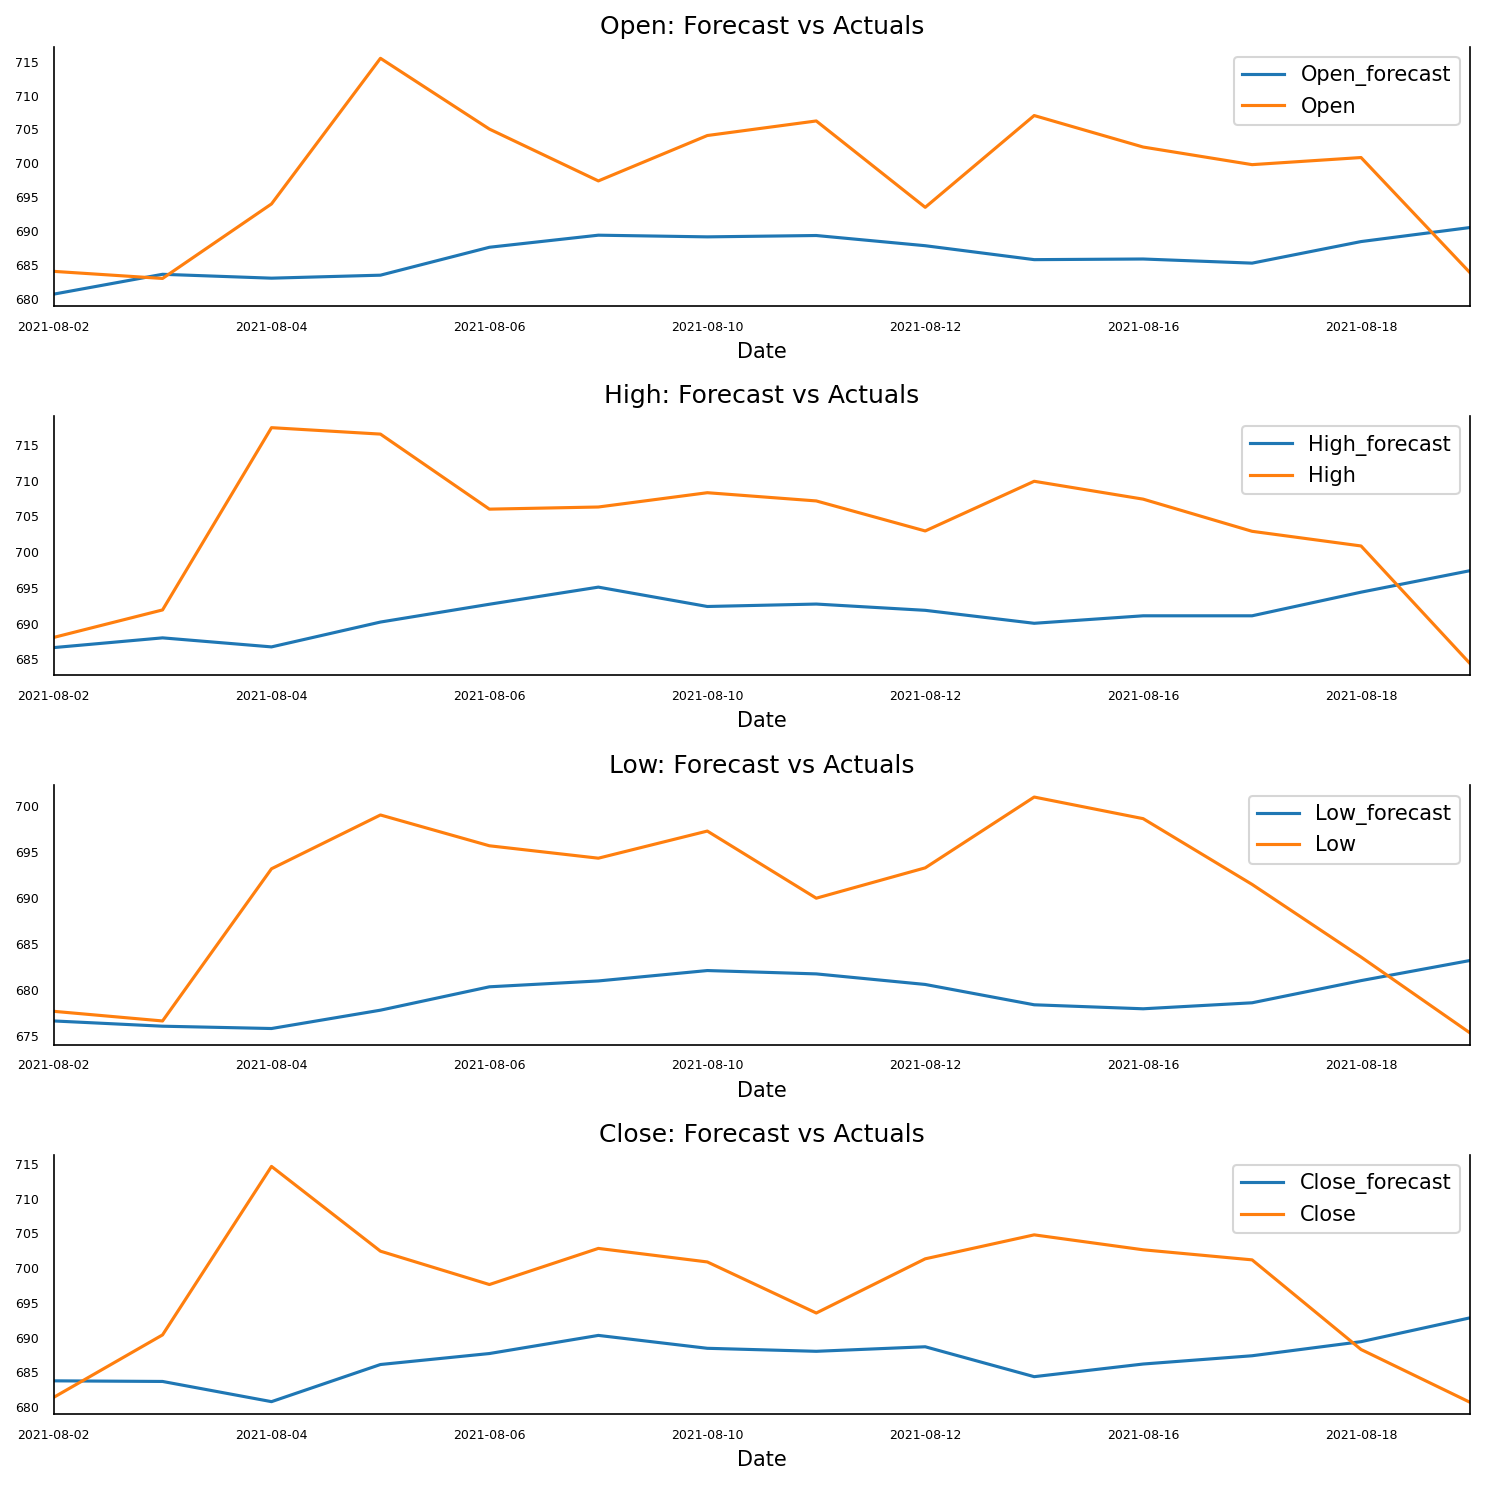

In [125]:
 fig, axes = plt.subplots(nrows=4, ncols=1, dpi=150, figsize=(10,10))
 for i, (col,ax) in enumerate(zip(df_stock_var.columns, axes.flatten())):
   df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
   df_stock_var_test[col][-nobs:].plot(legend=True, ax=ax);
   ax.set_title(col + ": Forecast vs Actuals")
   ax.xaxis.set_ticks_position('none')
   ax.yaxis.set_ticks_position('none')
   ax.spines["top"].set_alpha(0)
   ax.tick_params(labelsize=6)

plt.tight_layout();

##*Evaluating the model*

In [126]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual): 
    rmse = np.mean((forecast - actual)**2)**.5  
    rmse_p = (rmse/np.mean(actual))*100
    return({'rmse':rmse,'rmse_mean':rmse_p})

print('Forecast Accuracy of Open')
accuracy_prod = forecast_accuracy(df_results['Open_forecast'].values, df_stock_var_test['Open'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of High')
accuracy_prod = forecast_accuracy(df_results['High_forecast'].values, df_stock_var_test['High'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Low')
accuracy_prod = forecast_accuracy(df_results['Low_forecast'].values, df_stock_var_test['Low'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Close')
accuracy_prod = forecast_accuracy(df_results['Close_forecast'].values, df_stock_var_test['Close'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))



Forecast Accuracy of Open
rmse :  15.1248
rmse_mean :  2.1658

Forecast Accuracy of High
rmse :  15.9203
rmse_mean :  2.2628

Forecast Accuracy of Low
rmse :  14.1371
rmse_mean :  2.0473

Forecast Accuracy of Close
rmse :  14.8567
rmse_mean :  2.1305


#**Linear Regression**

In [127]:
df_stock_train_lin=df_stock.loc['2016-01-01':'2021-07-31'].copy()
df_stock_test_lin=df_stock.loc['2021-07-31':].copy()


##*Normalize the data*

In [128]:
from sklearn.preprocessing import MinMaxScaler

In [129]:
scaler = MinMaxScaler()
df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.fit_transform(df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])
df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.transform(df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])

In [130]:
df_stock_train_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,0.133345,0.134856,0.135370,239.090912,0.017090,4,1,1,0.091661,0.049976
2016-01-04,0.132825,0.130948,0.129499,232.318176,0.029120,0,4,1,0.090919,0.064715
2016-01-05,0.124600,0.124262,0.124330,233.363632,0.027480,1,5,1,0.086044,0.052656
2016-01-06,0.123128,0.122959,0.119949,227.363632,0.057049,2,6,1,0.066755,0.076103
2016-01-07,0.107542,0.107242,0.109259,224.318176,0.059934,3,7,1,0.070447,0.036578


In [131]:
df_stock_test_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2021-08-02,0.983903,0.991499,0.989591,681.400024,0.028814,0,2,8,1.023069,0.127487
2021-08-03,0.981903,0.998854,0.987567,690.400024,0.031664,1,3,8,1.037370,0.199705
2021-08-04,1.002857,1.047569,1.019469,714.650024,0.096645,2,4,8,1.041369,0.331614
2021-08-05,1.043813,1.045849,1.030745,702.450012,0.058303,3,5,8,1.035070,0.232130
2021-08-06,1.023907,1.025790,1.024288,697.650024,0.047550,4,6,8,1.037309,0.126750


##*Checking for multicollinearity*

In [132]:
from statsmodels.stats.outliers_influence import variance_inflation_factor    

def calculate_vif_(X, thresh=10,verbose=True):
    cols = X.columns
    variables = np.arange(X.shape[1])
    dropped=True
    while dropped:
        dropped=False
        c = X[cols[variables]].values
        vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]
        

        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            if verbose == True:
                print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
            variables = np.delete(variables, maxloc)
            dropped=True
    if verbose == True:
        print('Remaining variables:')
        print(X.columns[variables])
    return X[cols[variables]]

##*Model Generation*

In [133]:
def forward_regression(X, y,
                       threshold_in,
                       verbose=False):
    initial_list = []
    included = list(initial_list)
    while True:
        changed=False
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        if not changed:
            break

    return included

In [134]:
def backward_regression(X, y,
                           threshold_out,
                           verbose=False):
    included=list(X.columns)
    while True:
        changed=False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() 
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [135]:
def model_generator(df_train,df_test):
    train_dummy=pd.get_dummies(df_train,columns=['Day of Week','Day of Month','Month'])
    test_dummy = pd.get_dummies(df_test,columns=['Day of Week','Day of Month','Month'])
    for i in [1,2,3,4,5,6,7,9,10,11,12]:
        test_dummy['Month_'+str(i)] = 0
        test_dummy['Month_'+str(i)] = test_dummy['Month_'+str(i)].astype('uint8')
    for i in range(1,32):
      if (i not in df_test['Day of Month'].unique()):
        test_dummy['Day of Month_'+str(i)] = 0
        test_dummy['Day of Month_'+str(i)] = test_dummy['Day of Month_'+str(i)].astype('uint8')   
    X=train_dummy.drop('Close',axis=1)
    y=train_dummy["Close"]
    X_f=calculate_vif_(X.select_dtypes(exclude='uint8'),10,False)
    X_f=pd.concat([X_f,X.iloc[:,6:]],axis=1)
    model=sm.OLS(y,X_f[backward_regression(X_f,y,0.01)],axis=1).fit()
    pred=model.predict(test_dummy[backward_regression(X_f,y,0.01)])
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(test_dummy['Close'], pred))
    rmse_pct= (rmse/np.mean(test_dummy['Close']))*100
    sig_var = model.pvalues.index.tolist()
    return model,sig_var,rmse_pct    

In [136]:
 model,variables,rmse_per = model_generator(df_stock_train_lin,df_stock_test_lin)

In [137]:
print(model.summary2())

                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.905     
Dependent Variable: Close            AIC:                13820.5476
Date:               2021-09-15 12:16 BIC:                13883.2096
No. Observations:   1369             Log-Likelihood:     -6898.3   
Df Model:           11               F-statistic:        1181.     
Df Residuals:       1357             Prob (F-statistic): 0.00      
R-squared:          0.905            Scale:              1406.4    
-------------------------------------------------------------------
                 Coef.   Std.Err.    t     P>|t|   [0.025   0.975] 
-------------------------------------------------------------------
NIFTY50         482.3754   4.7219 102.1566 0.0000 473.1123 491.6384
Range           156.6363  11.2635  13.9066 0.0000 134.5406 178.7320
Day of Week_0   125.4994   3.1850  39.4035 0.0000 119.2514 131.7475
Day of Week_1   127.6273   3.1494  40.5248 0.0000 121.4492 133.805

In [138]:
print("Significance Variables :",'\n',*variables,sep='\n')

Significance Variables :


NIFTY50
Range
Day of Week_0
Day of Week_1
Day of Week_2
Day of Week_3
Day of Week_4
Month_1
Month_2
Month_3
Month_11
Month_12


In [139]:
print("RMSE Percentage",rmse_per,sep='\n')

RMSE Percentage
4.8726233052463614
